# 02 Exploratory Data Analysis

This notebook explores the cleaned 2025 Stack Overflow Developer Survey data prepared in `01_data_check.ipynb`.

The goal is to understand patterns in:
- job satisfaction
- career change consideration
- learning pathways
- compensation

Learning pathway flags are **not mutually exclusive**. Respondents may select multiple learning methods, so pathway charts should be interpreted descriptively rather than as separate independent groups.

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Cleaned Data

In [65]:
df = pd.read_csv("../data/processed/stackoverflow_2025_project_cleaned.csv")

df.head()

,ResponseId,JobSat,NewRole,LearnCodeChoose,LearnCode,LearnCodeAI,EdLevel,YearsCode,WorkExp,ConvertedCompYearly,...,WorkExp_clean,YearsCode_clean,learned_online_courses,learned_school,learned_bootcamp,learned_ai,learned_docs,learned_on_job,learned_books,learned_videos
0,1,10.0,I have neither consider or transitioned into a...,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...","Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",14.0,8.0,61256.0,...,8.0,14.0,1,0,0,0,0,0,0,0
1,2,9.0,I have transitioned into a new career and/or i...,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...","Associate degree (A.A., A.S., etc.)",10.0,2.0,104413.0,...,2.0,10.0,1,0,0,0,0,0,1,1
2,3,8.0,I have transitioned into a new career and/or i...,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...","Bachelor’s degree (B.A., B.S., B.Eng., etc.)",12.0,10.0,53061.0,...,10.0,12.0,1,0,0,0,1,0,0,1
3,4,6.0,I have neither consider or transitioned into a...,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...","Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5.0,4.0,36197.0,...,4.0,5.0,0,0,0,1,1,0,0,1
4,5,7.0,I have neither consider or transitioned into a...,"No, I am not new to coding and did not learn n...",Missing,"Yes, I learned how to use AI-enabled tools for...","Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",22.0,21.0,60000.0,...,21.0,22.0,0,0,0,0,0,0,0,0


In [66]:
df.shape

(49191, 32)

In [67]:
df.columns.tolist()

['ResponseId',
 'JobSat',
 'NewRole',
 'LearnCodeChoose',
 'LearnCode',
 'LearnCodeAI',
 'EdLevel',
 'YearsCode',
 'WorkExp',
 'ConvertedCompYearly',
 'Age',
 'Employment',
 'DevType',
 'OrgSize',
 'RemoteWork',
 'Country',
 'AISelect',
 'AIThreat',
 'high_job_sat',
 'career_change_considered',
 'active_learner',
 'log_salary',
 'WorkExp_clean',
 'YearsCode_clean',
 'learned_online_courses',
 'learned_school',
 'learned_bootcamp',
 'learned_ai',
 'learned_docs',
 'learned_on_job',
 'learned_books',
 'learned_videos']

## Job Satisfaction Distribution

`JobSat` is a 0–10 scale measuring how satisfied respondents are in their current professional developer role.

In [68]:
jobsat_counts = df["JobSat"].value_counts(dropna=False).sort_index()
jobsat_counts

JobSat
0.0       242
1.0       165
2.0       439
3.0       811
4.0       803
5.0      1896
6.0      3230
7.0      5590
8.0      6972
9.0      3598
10.0     2924
NaN     22521
Name: count, dtype: int64

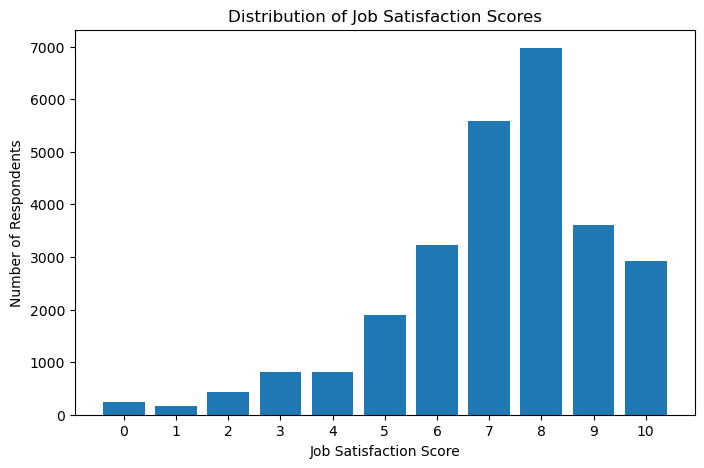

In [69]:
jobsat_counts_no_missing = df["JobSat"].dropna().value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(jobsat_counts_no_missing.index, jobsat_counts_no_missing.values)
plt.xlabel("Job Satisfaction Score")
plt.ylabel("Number of Respondents")
plt.title("Distribution of Job Satisfaction Scores")
plt.xticks(range(0, 11))
plt.show()

In [70]:
df["JobSat"].describe()

count    26670.000000
mean         7.201950
std          1.997245
min          0.000000
25%          6.000000
50%          8.000000
75%          8.000000
max         10.000000
Name: JobSat, dtype: float64

## Career Change Consideration

The `NewRole` column asks whether respondents considered a career change or transitioned into a new career or industry in the past year. This project converts that response into a binary variable called `career_change_considered`.

This should **not** be described as attrition or retention. It is a career-change consideration/transition signal.

In [71]:
df["NewRole"].value_counts(dropna=False)

NewRole
I have neither consider or transitioned into a new career or industry          16205
NaN                                                                            13664
I have somewhat considered changing my career and/or the industry I work in    10233
I have strongly considered changing my career and/or the industry I work in     5253
I have transitioned into a new career and/or industry voluntarily               3111
I have transitioned into a new career and/or industry involuntarily              725
Name: count, dtype: int64

In [72]:
career_counts = df["career_change_considered"].value_counts(dropna=False)
career_counts

career_change_considered
1.0    19322
0.0    16205
NaN    13664
Name: count, dtype: int64

In [73]:
career_labels = {
    0.0: "No career change considered",
    1.0: "Considered or transitioned"
}

career_counts_labeled = (
    df["career_change_considered"]
    .map(career_labels)
    .value_counts(dropna=False)
)

career_counts_labeled

career_change_considered
Considered or transitioned     19322
No career change considered    16205
NaN                            13664
Name: count, dtype: int64

In [74]:
career_percent = (
    df["career_change_considered"]
    .map(career_labels)
    .value_counts(normalize=True, dropna=True)
    * 100
).round(1)

career_percent

career_change_considered
Considered or transitioned     54.4
No career change considered    45.6
Name: proportion, dtype: float64

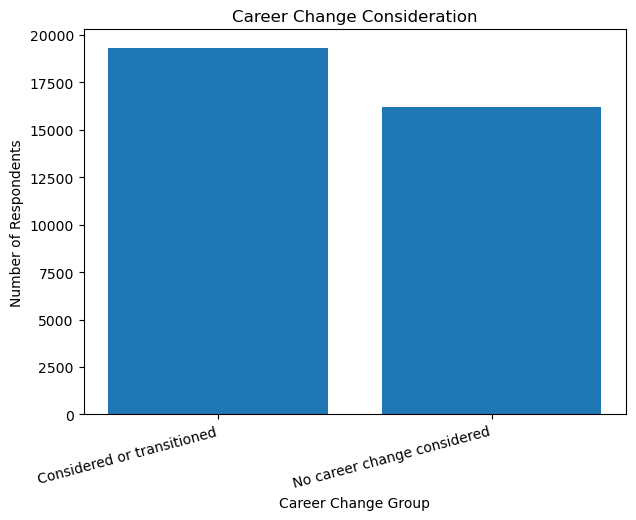

In [75]:
career_counts_plot = (
    df["career_change_considered"]
    .map(career_labels)
    .value_counts()
)

plt.figure(figsize=(7, 5))
plt.bar(career_counts_plot.index, career_counts_plot.values)
plt.xlabel("Career Change Group")
plt.ylabel("Number of Respondents")
plt.title("Career Change Consideration")
plt.xticks(rotation=15, ha="right")
plt.show()

Among respondents who answered the `NewRole` question, slightly more than half reported that they had either considered a career or industry change or had transitioned into a new career or industry in the past year. This makes the variable useful for classification because the target is relatively balanced rather than being dominated by one class.

## Job Satisfaction and Career Change Consideration

This section compares job satisfaction between respondents who did and did not consider or transition into a new career or industry.

In [76]:
jobsat_by_career_table = (
    df.dropna(subset=["career_change_considered", "JobSat"])
    .assign(career_group=lambda x: x["career_change_considered"].map(career_labels))
    .groupby("career_group")["JobSat"]
    .agg(["count", "mean", "median", "std"])
)

jobsat_by_career_table

,count,mean,median,std
career_group,,,,
Considered or transitioned,14134,6.695132,7.0,2.096270
No career change considered,12178,7.785104,8.0,1.687323


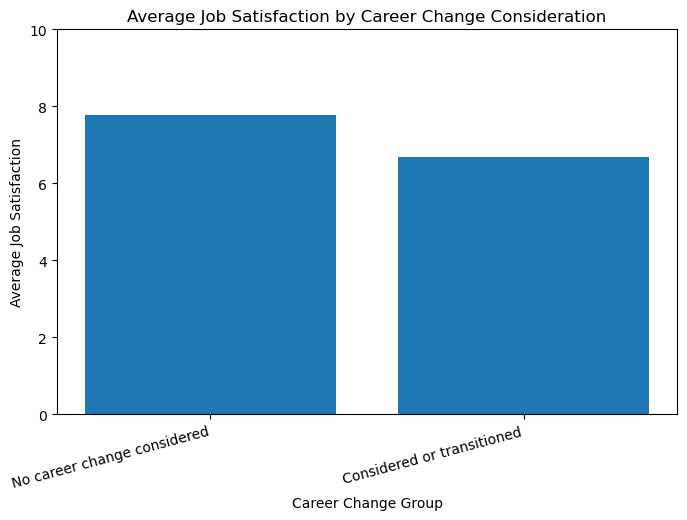

In [77]:
jobsat_by_career = jobsat_by_career_table["mean"].sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(jobsat_by_career.index, jobsat_by_career.values)
plt.xlabel("Career Change Group")
plt.ylabel("Average Job Satisfaction")
plt.title("Average Job Satisfaction by Career Change Consideration")
plt.ylim(0, 10)
plt.xticks(rotation=15, ha="right")
plt.show()

Respondents who did not consider or transition into a new career or industry reported higher average job satisfaction than those who did. This supports using job satisfaction as a meaningful workforce outcome in the project.

## Learning Pathway EDA

This section explores how respondents learned to code. These pathway flags are not mutually exclusive. A respondent may appear in multiple categories.

In [78]:
learning_pathway_flags = {
    "learned_online_courses": "Online Courses or Certification",
    "learned_school": "School",
    "learned_bootcamp": "Coding Bootcamp",
    "learned_ai": "AI CodeGen",
    "learned_docs": "Technical documentation",
    "learned_on_job": "Colleague",
    "learned_books": "Books",
    "learned_videos": "Videos",
}

pretty_learning_labels = {
    "learned_online_courses": "Online courses/certification",
    "learned_school": "School/university",
    "learned_bootcamp": "Coding bootcamp",
    "learned_ai": "AI tools",
    "learned_docs": "Technical documentation",
    "learned_on_job": "On-the-job/colleague",
    "learned_books": "Books/physical media",
    "learned_videos": "Videos",
}

# Recreate the pathway flags if they are missing from the saved file.
# This makes the EDA notebook more robust after a kernel restart.
for flag_col, label in learning_pathway_flags.items():
    if flag_col not in df.columns:
        df[flag_col] = df["LearnCode"].str.contains(label, na=False).astype(int)

learning_flags = list(learning_pathway_flags.keys())

### Learning Pathway Counts

This table shows how often each learning pathway appears in the survey responses.

In [79]:
learning_counts = df[learning_flags].sum().sort_values(ascending=False)
learning_counts_pretty = learning_counts.rename(index=pretty_learning_labels)
learning_counts_pretty

Technical documentation         22739
Videos                          16771
AI tools                        14753
Online courses/certification    10973
Books/physical media            10187
On-the-job/colleague             8596
School/university                5561
Coding bootcamp                  1747
dtype: int64

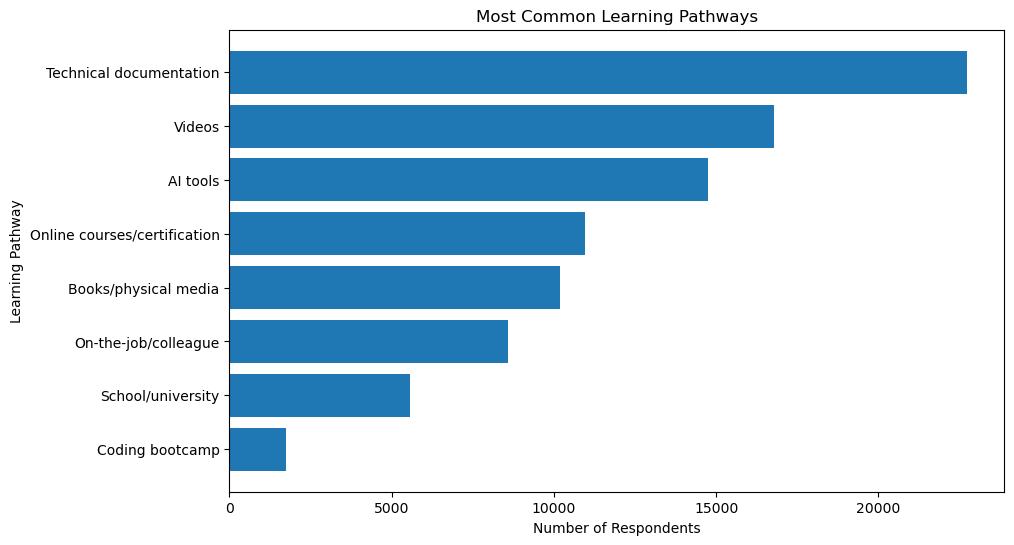

In [80]:
plt.figure(figsize=(10, 6))
plt.barh(learning_counts_pretty.index, learning_counts_pretty.values)
plt.xlabel("Number of Respondents")
plt.ylabel("Learning Pathway")
plt.title("Most Common Learning Pathways")
plt.gca().invert_yaxis()
plt.show()

Technical documentation, videos, AI tools, and online courses/certifications appear more often than formal school or coding bootcamp pathways. Because respondents could select more than one pathway, these counts should be interpreted as descriptive learning signals rather than mutually exclusive groups.

### Job Satisfaction by Learning Pathway

In [81]:
jobsat_by_pathway = {}

for col in learning_flags:
    jobsat_by_pathway[col] = df.loc[df[col] == 1, "JobSat"].mean()

jobsat_by_pathway = pd.Series(jobsat_by_pathway).sort_values(ascending=False)
jobsat_by_pathway_pretty = jobsat_by_pathway.rename(index=pretty_learning_labels)

jobsat_by_pathway_pretty

On-the-job/colleague            7.332916
AI tools                        7.204803
Technical documentation         7.203877
Coding bootcamp                 7.178191
School/university               7.161131
Videos                          7.153579
Books/physical media            7.138357
Online courses/certification    7.130618
dtype: float64

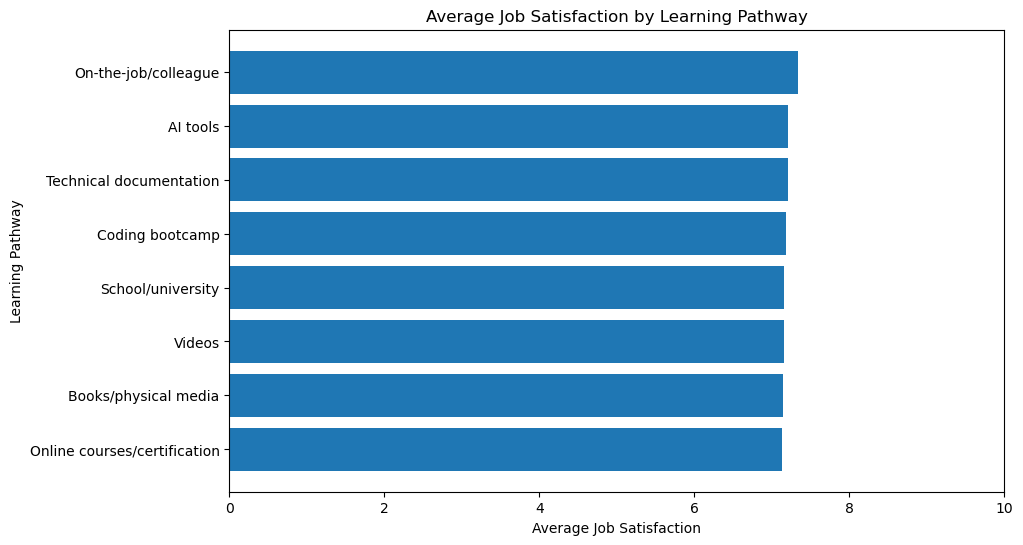

In [82]:
plt.figure(figsize=(10, 6))
plt.barh(jobsat_by_pathway_pretty.index, jobsat_by_pathway_pretty.values)
plt.xlabel("Average Job Satisfaction")
plt.ylabel("Learning Pathway")
plt.title("Average Job Satisfaction by Learning Pathway")
plt.xlim(0, 10)
plt.gca().invert_yaxis()
plt.show()

Average job satisfaction differs slightly across learning pathways, but these comparisons are descriptive only. Later modeling will account for other factors such as experience, compensation, education, and workplace characteristics.

### Career Change Consideration by Learning Pathway

In [83]:
career_by_pathway = {}

for col in learning_flags:
    career_by_pathway[col] = df.loc[df[col] == 1, "career_change_considered"].mean() * 100

career_by_pathway = pd.Series(career_by_pathway).sort_values(ascending=False)
career_by_pathway_pretty = career_by_pathway.rename(index=pretty_learning_labels)

career_by_pathway_pretty

Coding bootcamp                 65.200000
Online courses/certification    61.371158
AI tools                        58.471703
Books/physical media            57.809178
On-the-job/colleague            56.952965
Videos                          56.606070
Technical documentation         56.211779
School/university               52.882752
dtype: float64

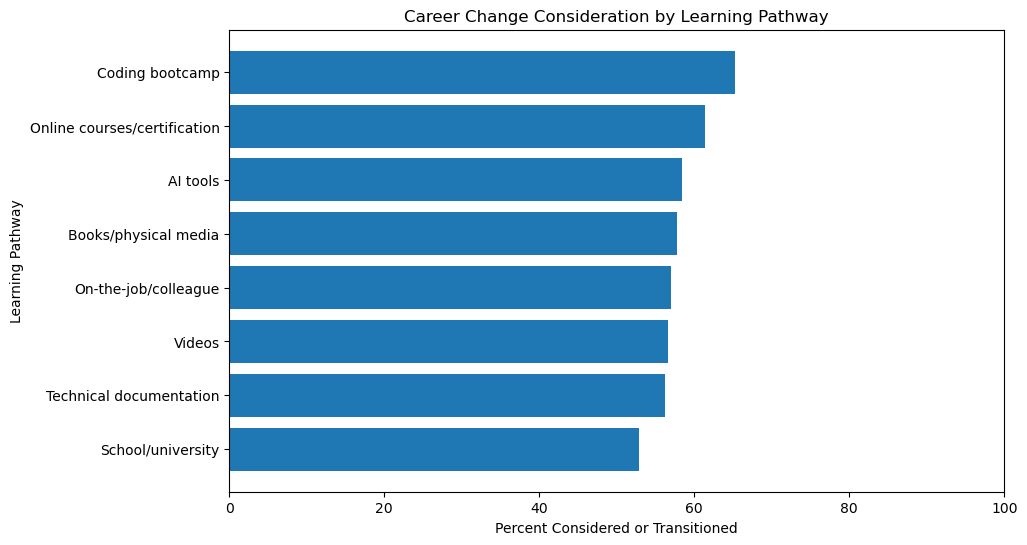

In [84]:
plt.figure(figsize=(10, 6))
plt.barh(career_by_pathway_pretty.index, career_by_pathway_pretty.values)
plt.xlabel("Percent Considered or Transitioned")
plt.ylabel("Learning Pathway")
plt.title("Career Change Consideration by Learning Pathway")
plt.xlim(0, 100)
plt.gca().invert_yaxis()
plt.show()

## Compensation Sanity Check

Compensation contains major outliers, so the project keeps the original annual compensation column for EDA and uses `log_salary` as a better-behaved modeling feature.

In [85]:
df["ConvertedCompYearly"].describe()

count    2.394700e+04
mean     1.017615e+05
std      4.617569e+05
min      1.000000e+00
25%      3.817100e+04
50%      7.532000e+04
75%      1.205960e+05
max      5.000000e+07
Name: ConvertedCompYearly, dtype: float64

In [86]:
df["log_salary"].describe()

count    49191.000000
mean        11.043736
std          1.112361
min          0.693147
25%         11.229514
50%         11.229514
75%         11.229514
max         17.727534
Name: log_salary, dtype: float64

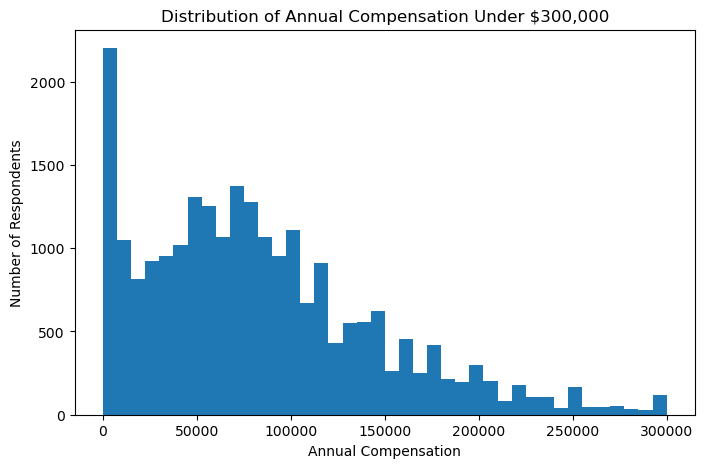

In [87]:
salary_under_300k = df[df["ConvertedCompYearly"] <= 300000]["ConvertedCompYearly"].dropna()

plt.figure(figsize=(8, 5))
plt.hist(salary_under_300k, bins=40)
plt.xlabel("Annual Compensation")
plt.ylabel("Number of Respondents")
plt.title("Distribution of Annual Compensation Under $300,000")
plt.show()

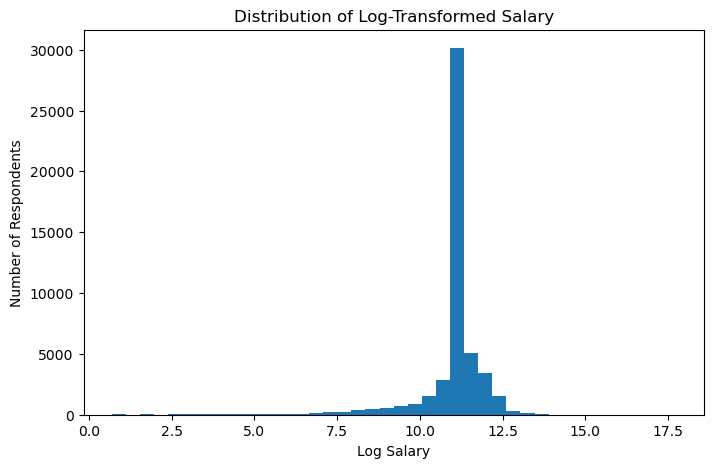

In [88]:
plt.figure(figsize=(8, 5))
plt.hist(df["log_salary"].dropna(), bins=40)
plt.xlabel("Log Salary")
plt.ylabel("Number of Respondents")
plt.title("Distribution of Log-Transformed Salary")
plt.show()

## Career Change Consideration by Coding Experience

Because career stage appeared important in the model, I grouped respondents by years of coding experience to examine whether career change consideration differed between newer and more experienced developers.

In [89]:
# Create coding experience groups
df["coding_experience_group"] = pd.cut(
    df["YearsCode_clean"],
    bins=[0, 2, 5, 10, 20, 60],
    labels=[
        "0-2 years",
        "3-5 years",
        "6-10 years",
        "11-20 years",
        "20+ years"
    ],
    include_lowest=True
)

experience_career_summary = (
    df.dropna(subset=["coding_experience_group", "career_change_considered"])
    .groupby("coding_experience_group")["career_change_considered"]
    .agg(["count", "mean"])
)

experience_career_summary["percent_considered"] = (
    experience_career_summary["mean"] * 100
).round(1)

experience_career_summary

C:\Users\patri\AppData\Local\Temp\ipykernel_11036\2599758399.py:17: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,count,mean,percent_considered
coding_experience_group,,,
0-2 years,1282,0.619345,61.9
3-5 years,3925,0.543185,54.3
6-10 years,8375,0.560955,56.1
11-20 years,11708,0.569781,57.0
20+ years,10193,0.490435,49.0


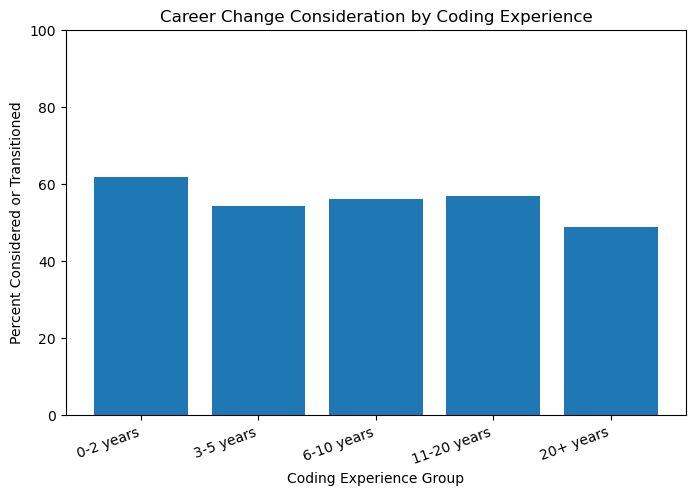

In [90]:
plt.figure(figsize=(8, 5))
plt.bar(
    experience_career_summary.index.astype(str),
    experience_career_summary["percent_considered"]
)

plt.xlabel("Coding Experience Group")
plt.ylabel("Percent Considered or Transitioned")
plt.title("Career Change Consideration by Coding Experience")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 100)
plt.show()

In [91]:
df["ai_threat_yes"] = np.where(
    df["AIThreat"].str.contains("Yes", case=False, na=False),
    1,
    0
)

In [92]:
corr_cols = [
    "JobSat",
    "career_change_considered",
    "ai_threat_yes",
    "YearsCode_clean",
    "WorkExp_clean",
    "log_salary",
    "learned_online_courses",
    "learned_school",
    "learned_bootcamp",
    "learned_ai",
    "learned_docs",
    "learned_on_job",
    "learned_books",
    "learned_videos"
]

corr_df = df[corr_cols].copy()

corr_matrix = corr_df.corr()

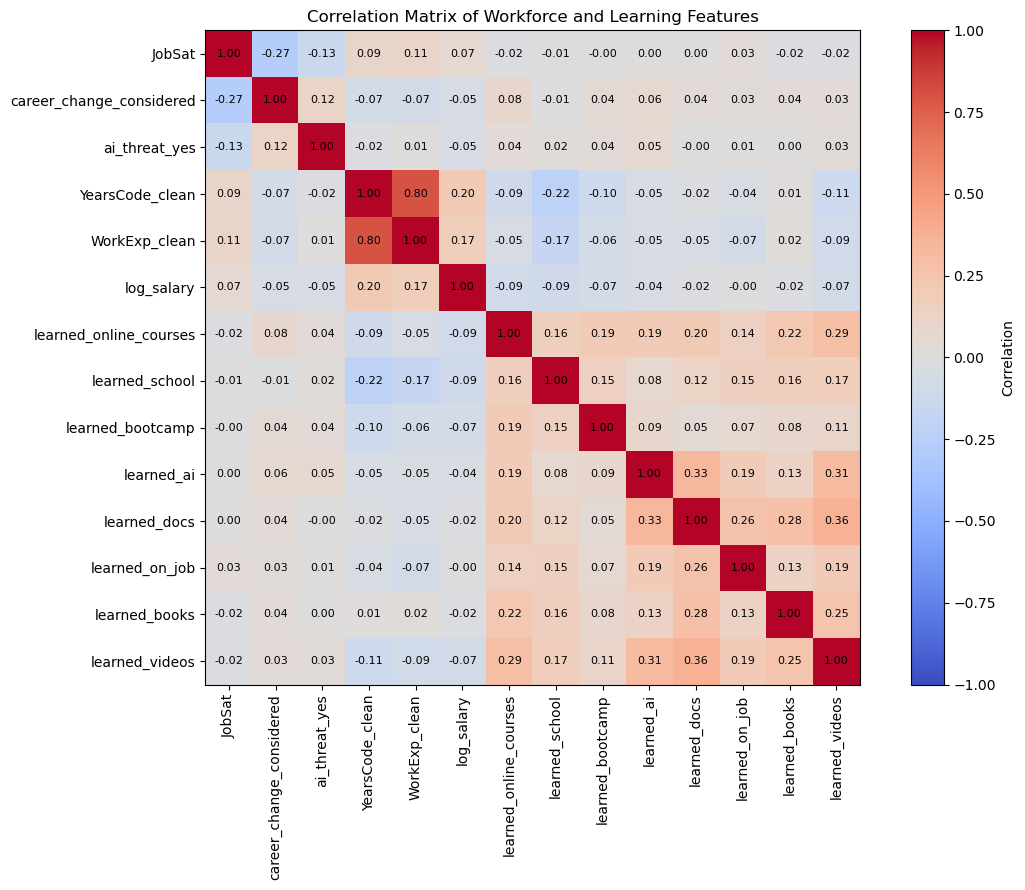

In [93]:
plt.figure(figsize=(12, 9))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j, i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Correlation Matrix of Workforce and Learning Features")
plt.tight_layout()
plt.show()

## EDA Summary

Initial exploratory analysis showed that the dataset supports the planned capstone.

Key observations:
- Job satisfaction is concentrated toward the higher end of the 0–10 scale.
- The career change consideration target is relatively balanced among respondents who answered the question.
- Respondents who did not consider or transition into a new career or industry reported higher average job satisfaction.
- Learning pathways vary widely, with technical documentation, videos, AI tools, and online courses/certifications appearing most often.
- Learning pathway groups overlap, so pathway charts are descriptive rather than causal.
- Compensation has large outliers, so log-transformed salary is more appropriate for modeling than raw annual compensation.

FileNotFoundError: [Errno 2] No such file or directory: 'img/career_change_factors.png'

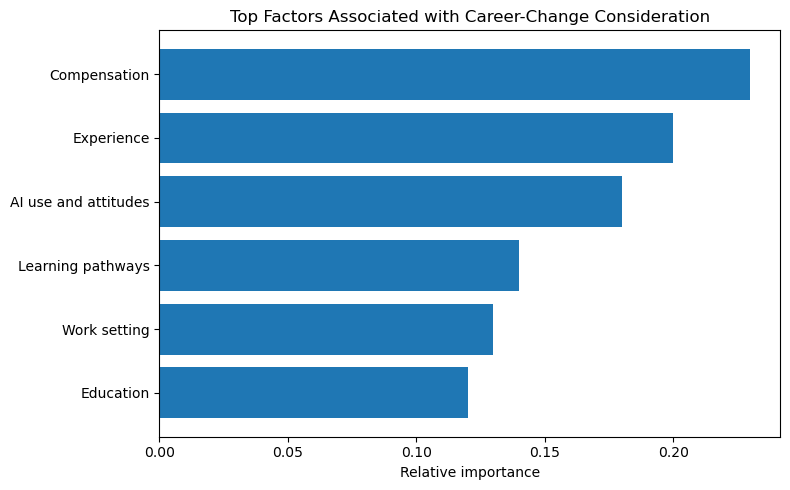

In [94]:
import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "feature": [
        "Compensation",
        "Experience",
        "AI use and attitudes",
        "Learning pathways",
        "Work setting",
        "Education"
    ],
    "importance": [0.23, 0.20, 0.18, 0.14, 0.13, 0.12]
})

importance_df = importance_df.sort_values("importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.xlabel("Relative importance")
plt.title("Top Factors Associated with Career-Change Consideration")
plt.tight_layout()
plt.savefig("img/career_change_factors.png", dpi=300, bbox_inches="tight")
plt.show()

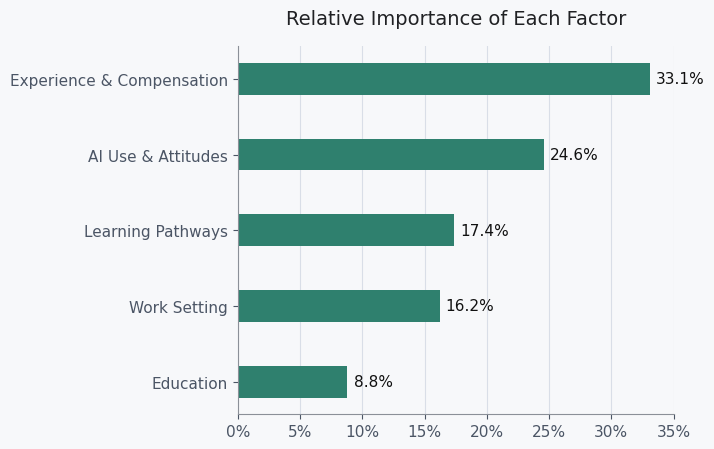

In [95]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Create folder if needed
os.makedirs("img", exist_ok=True)

# Data from your slide
factor_df = pd.DataFrame({
    "Factor": [
        "Education",
        "Work Setting",
        "Learning Pathways",
        "AI Use & Attitudes",
        "Experience & Compensation"
    ],
    "Relative Importance": [8.8, 16.2, 17.4, 24.6, 33.1]
})

# Keep order from smallest to largest so largest appears at bottom
factor_df = factor_df.sort_values("Relative Importance", ascending=True)

# Colors to match your deck
bar_color = "#2F806E"      # muted green/teal
text_color = "#1E2E4F"     # navy
grid_color = "#D9DEE7"     # light gray

fig, ax = plt.subplots(figsize=(7.2, 4.6))

# Background
fig.patch.set_facecolor("#F7F8FA")
ax.set_facecolor("#F7F8FA")

# Bars
bars = ax.barh(
    factor_df["Factor"],
    factor_df["Relative Importance"],
    color=bar_color,
    height=0.42
)

# Title
ax.set_title(
    "Relative Importance of Each Factor",
    fontsize=14,
    pad=16,
    color="#202124"
)

# X-axis percent formatting
ax.set_xlim(0, 35)
ax.xaxis.set_major_locator(plt.MultipleLocator(5))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))

# Gridlines
ax.grid(axis="x", color=grid_color, linewidth=0.8)
ax.set_axisbelow(True)

# Remove extra borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#8B9098")
ax.spines["bottom"].set_color("#8B9098")

# Tick styling
ax.tick_params(axis="x", labelsize=11, colors="#4B5565")
ax.tick_params(axis="y", labelsize=11, colors="#4B5565")

# Value labels at end of bars
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        ha="left",
        fontsize=11,
        color="#111111"
    )

# No axis labels
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig("img/career_change_factors.png", dpi=300, bbox_inches="tight")
plt.show()

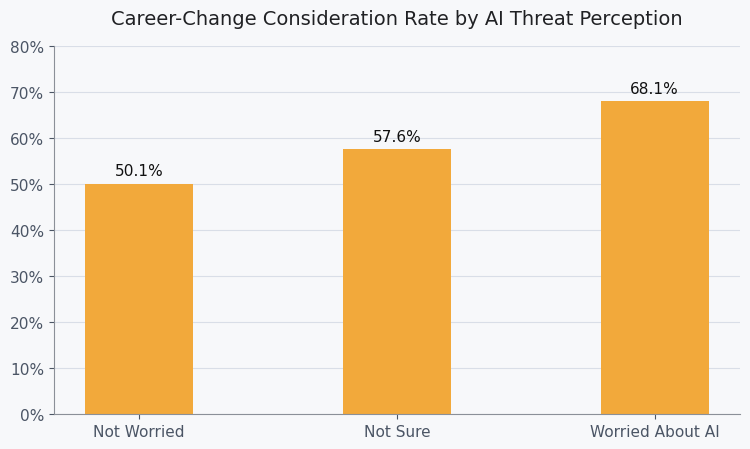

In [97]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

os.makedirs("img", exist_ok=True)

# Start from actual data
ai_df = df.dropna(subset=["AIThreat", "career_change_considered"]).copy()

# Optional: simplify the AIThreat labels
ai_df["AI Threat Perception"] = ai_df["AIThreat"].map({
    "No": "Not Worried",
    "I'm not sure": "Not Sure",
    "Yes": "Worried About AI"
})

# If your labels are slightly different, check them with:
# print(df["AIThreat"].value_counts(dropna=False))

# Calculate observed career-change consideration rate
ai_summary = (
    ai_df.dropna(subset=["AI Threat Perception"])
         .groupby("AI Threat Perception")["career_change_considered"]
         .mean()
         .reset_index()
)

ai_summary["Career-Change Rate"] = ai_summary["career_change_considered"] * 100

# Set display order
order = ["Not Worried", "Not Sure", "Worried About AI"]
ai_summary["AI Threat Perception"] = pd.Categorical(
    ai_summary["AI Threat Perception"],
    categories=order,
    ordered=True
)
ai_summary = ai_summary.sort_values("AI Threat Perception")

# Deck colors
bar_color = "#F2A93B"
grid_color = "#D9DEE7"
background = "#F7F8FA"

fig, ax = plt.subplots(figsize=(7.6, 4.6))

fig.patch.set_facecolor(background)
ax.set_facecolor(background)

bars = ax.bar(
    ai_summary["AI Threat Perception"],
    ai_summary["Career-Change Rate"],
    color=bar_color,
    width=0.42
)

ax.set_title(
    "Career-Change Consideration Rate by AI Threat Perception",
    fontsize=14,
    pad=16,
    color="#202124"
)

ax.set_ylim(0, 80)
ax.yaxis.set_major_locator(plt.MultipleLocator(10))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))

ax.grid(axis="y", color=grid_color, linewidth=0.8)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#8B9098")
ax.spines["bottom"].set_color("#8B9098")

ax.tick_params(axis="x", labelsize=11, colors="#4B5565")
ax.tick_params(axis="y", labelsize=11, colors="#4B5565")

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1.2,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        color="#111111"
    )

ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig("img/ai_concern_chart.png", dpi=300, bbox_inches="tight")
plt.show()